## Importing the necessary libraries

In [1548]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import numpy as np


# Data preparation

## 1-Data Inspection

#### Load data

In [1549]:
df_hit_apartement=pd.read_csv('homeintunisia_appartement_vente.csv')
df_hit_maison=pd.read_csv('homeintunisia_maison_vente.csv')
df_hit_maison['house']=1
df_hit_apartement['house']=0
df_hit=pd.concat([df_hit_maison,df_hit_apartement])
df_hit = df_hit.reset_index(drop=True)


In [1550]:
df_mub_appartement=pd.read_csv('mubawab_apartement_vente.csv')
df_mub_maison=pd.read_csv('mubawab_maison_vente.csv')
df_mub_appartement['house']=0
df_mub_maison['house']=1
df_mub=pd.concat([df_mub_appartement,df_mub_maison])
df_mub = df_mub.reset_index(drop=True)

In [1551]:
df_star_appartement=pd.read_csv('properstar_appartement_acheter.csv')
df_star_maison=pd.read_csv('properstar_maison_acheter.csv')
df_star_appartement['house=']=0
df_star_maison['house']=1
df_star=pd.concat([df_star_appartement,df_star_maison])
df_star = df_star.reset_index(drop=True)


In [1552]:
df_remax_appartement=pd.read_csv('remax_apartement_vente.csv')
df_remax_maison=pd.read_csv('remax_maison_acheter.csv')
df_remax_appartement['house']=0
df_remax_maison['house']=1
df_remax=pd.concat([df_remax_appartement,df_remax_maison])
df_remax = df_remax.reset_index(drop=True)


In [1553]:
euro_to_dinar=3.38

#### Inspect data

In [1554]:
df_hit.head(3)

,link,title,address,price,type,Référence,Pièces,Surface,Surface totale,Type de chauffage,...,Terrain 572 m²,Terrains 2032 m²,Terrains 1000 m²,Terrains 1291 m²,Terrains 1293 m²,Terrains 1667 m²,Terrains 8940 m²,Terrains 5160 m²,Appartement 109 m²,house
0,https://www.homeintunisia.com/fr/propri%C3%A9t...,À Vendre – Villa spacieuse à Khzema,Sousse Khezama,1 300 000 TND,Maison,85853297,6 pièces,350 m²,450 m²,"Radiateur, Climatisation",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,https://www.homeintunisia.com/fr/propri%C3%A9t...,Villa neuve à vendre Kantaoui côté mer,El Kantaoui,2 400 000 TND,Maison,85839722,12 pièces,494 m²,600 m²,Central,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,https://www.homeintunisia.com/fr/propri%C3%A9t...,🏰 VILLA COLONIALE PRESTIGE AVEC PISCINE – LA M...,La Marsa,1 730 400 TND,Maison,85836272,9 pièces,600 m²,600 m²,"Radiateur, Central",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [1555]:
df_mub.head(3)

,link,title,address,price,m²,Chambres,Terrasse,Garage,Sécurité,Type de bien,...,Réfrigérateur,Machine à laver,Surface habitable,Orientation,Surface extérieure,Cheminée,Surface de la parcelle,house,Entre-seul,Nombre d'étages
0,https://www.mubawab.tn/fr/a/8033431/appartemen...,Appartement S2 à vendre aux Jardins de Carthage,Les Jardins de Carthage à Le Kram,480 000 TND,118.0,2.0,1.0,1.0,1.0,Appartement,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,https://www.mubawab.tn/fr/a/8125652/appartemen...,Appartement S3 à vendre aux Jardins de Carthage,Les Jardins de Carthage à Le Kram,720 000 TND,168.0,3.0,1.0,1.0,NaN,Appartement,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
2,https://www.mubawab.tn/fr/a/8139037/appartemen...,Appartement S1 Neuf à vendre aux Jardins de Ca...,Les Jardins de Carthage à Le Kram,335 000 TND,67.0,NaN,1.0,NaN,NaN,Appartement,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [1556]:
df_star.head(3)

,link,class,title,description,address,price,latitude,longitude,Pièces,Etages,...,Garage,house=,Piscine intérieure,Salle à manger,Hammam,Cave à vin,Piscine extérieure,Studio de yoga,Suites d'hôtes,house
0,https://www.properstar.fr/annonce/105771520,appartement,À Vendre – Appartement S+2 avec Place de Parki...,Appartement • 3 pce(s) • 83 m² • 3ème étage • ...,Hammam Sousse,87 407 €,35.886399,10.591507,3.0,4.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.properstar.fr/annonce/103256625,appartement,"Appartement à vendre à Sousse, Tunisie",Appartement • 3 pce(s) • 2 chambres • 1 sdb • ...,Sousse,96 566 €,35.824503,10.634584,3.0,5.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.properstar.fr/annonce/103304945,appartement,"Appartement à vendre à Hammamet, Tunisie",Appartement • 4 pce(s) • 3 chambres • 1 sdb • ...,Hammamet,139 283 €,36.407257,10.622471,4.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1557]:
df_remax.head(3)

,link,title,prix,payment_method,latitude,longitude,address,statut_marche,Nombre de pièces,Nombre de chambres,...,Four à barbecue,Dishwasher,Salle de jeux,Zone industrielle,Sauna,Nord,Art Deco,Montagnes,Vue sur montagne,Style colonial
0,https://www.remax.com.tn/fr-tn/biens/apparteme...,Appartement - Vente - Les Jardins du lac 2 Tun...,"850,000 TND",NaN,NaN,NaN,1053 - Les Jardins du lac 2 - Tunis - Tunisie,Nouveau sur le marché,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.remax.com.tn/fr-tn/biens/apparteme...,Appartement - Vente - Les Jardins du lac 2 Tun...,"820,000 TND",NaN,NaN,NaN,1053 - Les Jardins du lac 2 - Tunis - Tunisie,Nouveau sur le marché,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.remax.com.tn/fr-tn/biens/penthouse...,Penthouse - Vente - Les berges du lac 1 Tunis ...,"1,600,000 TND",NaN,36.839682,10.24668,1053 - Les berges du lac 1 - Tunis - Tunisie,Nouveau sur le marché,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### shape of the data (number of rows, number of columns)

In [1558]:
df_hit.shape

(424, 409)

In [1559]:
df_mub.shape

(9009, 52)

In [1560]:
df_star.shape

(1226, 59)

In [1561]:
df_remax.shape

(249, 135)

##### column names

In [1562]:
df_hit.columns

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       ...
       'Terrain 572 m²', 'Terrains 2032 m²', 'Terrains 1000 m²',
       'Terrains 1291 m²', 'Terrains 1293 m²', 'Terrains 1667 m²',
       'Terrains 8940 m²', 'Terrains 5160 m²', 'Appartement 109 m²', 'house'],
      dtype='object', length=409)

In [1563]:
df_star.columns

Index(['link', 'class', 'title', 'description', 'address', 'price', 'latitude',
       'longitude', 'Pièces', 'Etages', 'Habitable', 'Total', 'Ascenseur',
       'Climatisation', 'Parking', 'Type', 'Condition', 'Chauffage',
       'Eau chaude', 'Déchets des eaux usées', 'Chambres', 'Salles de bains',
       'Toilettes', 'Appartements', 'Places de parc extérieur', 'Terrain',
       'Alarme', 'Balcon', 'Internet', 'Meublé', 'Piscine',
       'Télévision par satellite', 'Terrasse', 'Année de construction',
       'Places de parc intérieures', 'Concierge 24/7', 'Interphone',
       'Standing', 'Année de rénovation', 'Lave-vaisselle', 'Jacuzzi',
       'Barbecue', 'Sécurité', 'Machine à laver',
       'Recharge de véhicules électriques', 'Sauna', 'Tennis',
       'Centre de remise en forme', 'Jardin', 'Garage', 'house=',
       'Piscine intérieure', 'Salle à manger', 'Hammam', 'Cave à vin',
       'Piscine extérieure', 'Studio de yoga', 'Suites d'hôtes', 'house'],
      dtype='object')

In [1564]:
df_mub.columns

Index(['link', 'title', 'address', 'price', 'm²', 'Chambres', 'Terrasse',
       'Garage', 'Sécurité', 'Type de bien', 'latitude', 'longitude',
       'Cuisine équipée', 'Chambre', 'Pièces', 'Salles de bains', 'Ascenseur',
       'Concierge', 'Meublé', 'Façade extérieure', 'Antenne parabolique',
       'Climatisation', 'Chauffage central', 'Double vitrage', 'Porte blindée',
       'Four', 'Micro-ondes', 'Etat', 'Etat du bien', 'Étage du bien',
       'Type du sol', 'Standing', 'État', 'Livraison:', 'Chambre rangement',
       'Salon européen', 'Vue sur mer', 'Salle de bain', 'Jardin', 'Piscine',
       'Vue sur les montagnes', 'Pièce', 'Réfrigérateur', 'Machine à laver',
       'Surface habitable', 'Orientation', 'Surface extérieure', 'Cheminée',
       'Surface de la parcelle', 'house', 'Entre-seul', 'Nombre d'étages'],
      dtype='object')

#### matching columns

In [1565]:
cols_mub=['price','address', 'm²', 'Pièces','Salles de bains','Salle de bain', 'Terrasse',
          'Meublé','Climatisation','Chauffage central', 'Sécurité',"Étage du bien","Nombre d'étages",
          'latitude', 'longitude', 'Chambres', 'Garage', 'Jardin', 'Piscine','house']
cols_renamed = {
    'm²': 'total_area',
    'Pièces': 'rooms',
    'Chambres': 'bedrooms',
    'Salles de bains': 'bathrooms',
    'Salle de bain': 'bathroom',
    'Jardin': 'garden',
    'Garage': 'garage',
    'Piscine': 'pool',
    'Chauffage central': 'heating',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'Terrasse': 'terrace',
    'Climatisation': 'air_conditioning',
    'Surface de la parcelle': 'total_area',  #
    'Meublé': 'furnished',
    "Sécurité":"security",
    "Étage du bien":"floor_a",
    "Nombre d'étages":"floor_b"
}
# Assuming df is your DataFrame
df_mub = df_mub[cols_mub].rename(columns=cols_renamed)
df_mub.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'bathroom',
       'terrace', 'furnished', 'air_conditioning', 'heating', 'security',
       'floor_a', 'floor_b', 'latitude', 'longitude', 'bedrooms', 'garage',
       'garden', 'pool', 'house'],
      dtype='object')

In [1566]:
hit_cols=df_hit.columns
hit_cols[0:20]

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       'Énergie de chauffage', 'Moyen de chauffage', 'Type d'eau chaude',
       'Moyen d'eau chaude', 'Eaux usées', 'État', 'Étage', 'Exposition',
       'Vue', 'Salon'],
      dtype='object')

In [1567]:
cols_hit=['price','Pièces','address','Surface totale','Salles de bains','Salle de bains','Étage',
    'Type de chauffage','Piscine','latitude','longitude','Air conditionné','Meublé',
    'Piscine en copropriété','Terrasse','Alarme','Vidéo surveillance','Garage','Jardin',
    'Chambres','house']
df_hit=df_hit[cols_hit]
# Using pandas rename method directly
df_hit = df_hit.rename(columns={
    'Pièces': 'rooms',
    'Surface totale': 'total_area',
    'Étage': 'floor_number',
    'Salon': 'living_room',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Piscine en copropriété': 'shared_pool',
    'Salles de bains':'bathrooms',
    'Salle de bains':'bathroom',
    'Type de chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'alarm',
    'Vidéo surveillance':'video_surveillance',
    'Garage':'garage',
    'Jardin':'garden'
})
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'bathrooms', 'bathroom',
       'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden', 'bedrooms', 'house'],
      dtype='object')

In [1568]:
df_star.columns

Index(['link', 'class', 'title', 'description', 'address', 'price', 'latitude',
       'longitude', 'Pièces', 'Etages', 'Habitable', 'Total', 'Ascenseur',
       'Climatisation', 'Parking', 'Type', 'Condition', 'Chauffage',
       'Eau chaude', 'Déchets des eaux usées', 'Chambres', 'Salles de bains',
       'Toilettes', 'Appartements', 'Places de parc extérieur', 'Terrain',
       'Alarme', 'Balcon', 'Internet', 'Meublé', 'Piscine',
       'Télévision par satellite', 'Terrasse', 'Année de construction',
       'Places de parc intérieures', 'Concierge 24/7', 'Interphone',
       'Standing', 'Année de rénovation', 'Lave-vaisselle', 'Jacuzzi',
       'Barbecue', 'Sécurité', 'Machine à laver',
       'Recharge de véhicules électriques', 'Sauna', 'Tennis',
       'Centre de remise en forme', 'Jardin', 'Garage', 'house=',
       'Piscine intérieure', 'Salle à manger', 'Hammam', 'Cave à vin',
       'Piscine extérieure', 'Studio de yoga', 'Suites d'hôtes', 'house'],
      dtype='object')

In [1569]:
cols_star=['price','address','latitude','longitude','Pièces','Etages','Chambres','Salles de bains',
        'Total','Piscine','Piscine intérieure', 'Terrasse','Jardin','Chauffage', 'Climatisation','Meublé',
        'Alarme','Garage','house']
df_star=df_star[cols_star]
# Using pandas rename method directly
df_star = df_star.rename(columns={
    'Pièces': 'rooms',
    'Total': 'total_area',
    'Étage': 'floor_number',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Climatisation': 'air_conditioning',
    'Meublé': 'furnished',
    'Salles de bains':'bathrooms',
    'Chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'security',
    'Garage':'garage',
    'Jardin':'garden',
    'Etages':'floor',
    'Piscine intérieure': 'indoor_pool'
})
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'bathrooms', 'bathroom',
       'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden', 'bedrooms', 'house'],
      dtype='object')

In [1570]:
remax_cols=df_remax.columns
remax_cols[0:30]

Index(['link', 'title', 'prix', 'payment_method', 'latitude', 'longitude',
       'address', 'statut_marche', 'Nombre de pièces', 'Nombre de chambres',
       'Nombre salles de bain', 'm²', 'Année de construction',
       'Places de parking', 'Nombre d'étages', 'Nombre de WC',
       'Air Conditionné', 'Chauffage', 'Cuisine équipée', 'Dressing',
       'Ascenseur', 'Rénové', 'Système de sécurité', 'Système d'alarme',
       'Balcon', 'Parking', 'Pièce de rangement', 'Habitation',
       'Surface constructible (m²)', 'Année/Mois de Construction'],
      dtype='object')

In [1571]:
cols_remax=['prix','latitude','longitude','Nombre de pièces','Nombre de chambres','Nombre salles de bain',
            'm²', 'Garage', 'Jardin', 'Terrasse','Air Conditionné',
            'Piscine','Meublé','Système de sécurité', 'Système de surveillance','Camera de sécurité',
            'Chauffage Central','Chauffage au sol',"Nombre d'étages",'house']
df_remax=df_remax[cols_remax]
# Using pandas rename method directly
df_remax = df_remax.rename(columns={
    'prix':'price',
    'Nombre de pièces': 'rooms',
    'm²': 'total_area',
    'Nombre de chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air Conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Nombre salles de bain':'bathrooms',
    'Terrasse':'terrace',
    'Alarme':'security',
    'Garage':'garage',
    'Jardin':'garden',
    "Nombre d'étages":'floor'
})
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'total_area', 'garage', 'garden', 'terrace', 'air_conditioning', 'pool',
       'furnished', 'Système de sécurité', 'Système de surveillance',
       'Camera de sécurité', 'Chauffage Central', 'Chauffage au sol', 'floor',
       'house'],
      dtype='object')

## 2- Data Cleaning

### a-standardizing Formats

#### -df_hit

In [1572]:
df_hit["price"].sample(5)

282    280 000 TND
274    120 000 TND
358    280 000 TND
180    452 880 TND
226    480 000 TND
Name: price, dtype: object

In [1573]:
print(df_hit.shape)
df_hit=df_hit[df_hit['price']!="Prix sur demande"]
print(df_hit.shape)

(424, 21)
(407, 21)


In [1574]:
# Filter rows where the price column contains the word "Moin"
mois_df = df_hit[df_hit['price'].astype(str).str.contains('Mois', case=False)]
jour_df=df_hit[df_hit['price'].astype(str).str.contains('Jour', case=False)]
semaine_df=df_hit[df_hit['price'].astype(str).str.contains('Semaine', case=False)]
year_df=df_hit[df_hit['price'].astype(str).str.contains('An', case=False)]
print(mois_df.shape)
print(jour_df.shape)
print(semaine_df.shape)

(0, 21)
(0, 21)
(0, 21)


In [1575]:
print(df_hit.shape)
df_hit = df_hit[~df_hit['price'].astype(str).str.contains('Mois|Jour|Semaine|An', case=False)]
print(df_hit.shape)

(407, 21)
(407, 21)


In [1576]:
# First, remove 'TND' from the price column
df_hit['price'] = df_hit['price'].str.replace('TND', '')
# Remove all types of spaces (including non-breaking spaces and other whitespace)
df_hit['price'] = df_hit['price'].str.replace(r'\s+', '', regex=True)
# Now convert to float
df_hit['price'] = df_hit['price'].astype(float)

In [1577]:
df_hit['rooms'].value_counts()

rooms
3 pièces     112
4 pièces      90
2 pièces      48
5 pièces      37
6 pièces      23
10 pièces     14
7 pièces      13
8 pièces      12
1 pièce       11
9 pièces       6
13 pièces      2
11 pièces      2
15 pièces      2
12 pièces      1
14 pièces      1
19 pièces      1
20 pièces      1
16 pièces      1
Name: count, dtype: int64

In [1578]:
df_hit['rooms']=df_hit['rooms'].str.replace(' pièces','')
df_hit['rooms']=df_hit['rooms'].str.replace(' pièce','')
df_hit['rooms']=df_hit['rooms'].astype(float)
df_hit['rooms'].value_counts()

rooms
3.0     112
4.0      90
2.0      48
5.0      37
6.0      23
10.0     14
7.0      13
8.0      12
1.0      11
9.0       6
13.0      2
11.0      2
15.0      2
12.0      1
14.0      1
19.0      1
20.0      1
16.0      1
Name: count, dtype: int64

In [1579]:
df_hit['total_area'].value_counts().head(3)

total_area
200 m²    7
450 m²    6
115 m²    6
Name: count, dtype: int64

In [1580]:
def clean_size_column(df_func, col):
    """
    Cleans a size-related column by:
    1. Removing 'm²' and any non-breaking spaces.
    2. Stripping leading/trailing spaces.
    3. Converting cleaned values to numeric (float).
    4. Handling missing or invalid values gracefully.
    """
    df_func[col] = df_func[col].astype(str)  # Convert all to string to prevent errors
    df_func[col] = df_func[col].str.replace('m²', '', regex=False)  # Remove 'm²'
    df_func[col] = df_func[col].str.replace('\u202f', '', regex=False)  # Remove non-breaking spaces
    df_func[col] = df_func[col].str.replace(' ', '', regex=False)  # Remove normal spaces
    df_func[col] = df_func[col].str.strip()  # Strip leading/trailing spaces
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  # Convert to float, setting errors to NaN
    return df_func
# Example usage
columns_to_transform = ['total_area']  # List of size-related columns
for col in columns_to_transform:
    df_hit = clean_size_column(df_hit, col)
# Check the cleaned columns
df_hit[columns_to_transform].sample(5)


,total_area
104,700.0
189,138.0
273,100.0
111,932.0
234,139.0


In [1581]:
df_hit['pool'] = df_hit[['pool', 'shared_pool']].max(axis=1)
df_hit.drop(columns=['shared_pool'],inplace=True)

In [1582]:
df_hit['bathrooms'] = df_hit[['bathroom', 'bathrooms']].max(axis=1)
df_hit.drop(columns=['bathroom'],inplace=True)

In [1583]:
df_hit['security']=0
df_hit['security']=df_hit[['video_surveillance', 'alarm']].max(axis=1)
df_hit=df_hit.drop(columns=['video_surveillance', 'alarm'],axis=1)
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'bathrooms', 'floor_number',
       'heating', 'pool', 'latitude', 'longitude', 'air_conditioning',
       'furnished', 'terrace', 'garage', 'garden', 'bedrooms', 'house',
       'security'],
      dtype='object')

In [1584]:
# Set to 1 for properties with any type of heating
df_hit["heating"]=df_hit["heating"].fillna(0)
df_hit["heating"]=df_hit["heating"].apply(lambda x: 0 if x=="Sans chauffage" else 1)
print(df_hit['heating'].value_counts())

heating
1    401
0      6
Name: count, dtype: int64


In [1585]:
df_hit['floor_number'].value_counts()

floor_number
Rez-de-chaussée               76
1er                           31
Plain-pied                    23
2ème                          20
4ème                          17
Rez-de-chaussée / 2 étages    16
Rez-de-chaussée / 1 étage     13
1er étage / 4                  9
3ème                           9
5ème                           6
2ème étage / 2                 5
3ème étage / 5                 5
3ème étage / 4                 5
2ème étage / 3                 5
4ème étage / 4                 5
Rez-de-chaussée / 3 étages     5
Plain-pied / 1 étage           4
Rez-de-jardin                  4
2ème étage / 5                 4
2ème étage / 4                 4
6ème                           3
Rez-de-chaussée / 5 étages     3
3ème étage / 3                 3
1er étage / 3                  3
7ème étage / 7                 3
4ème étage / 6                 3
1er étage / 2                  3
1er étage / 7                  3
9ème                           2
Rez-de-jardin / 2 étages      

In [1586]:
import re

# Create a new column for the extracted floor number
df_hit['floor_numeric'] = None

# Function to extract floor number
def extract_floor_number(floor_str):
    if not isinstance(floor_str, str):
        return None
        
    # Handle special cases
    if 'Rez-de-chaussée' in floor_str or 'Rez-de-jardin' in floor_str:
        return 0
    if 'Plain-pied' in floor_str:
        return 0
    if 'Surélevé' in floor_str:
        return 0.5
        
    # Extract floor number from strings like "1er", "2ème", etc.
    match = re.search(r'^(\d+)', floor_str)
    if match:
        return int(match.group(1))
        
    # Extract from patterns like "2ème étage / 4"
    match = re.search(r'^(\d+)[^\d]+', floor_str)
    if match:
        return int(match.group(1))
        
    return None

# Apply the function to the floor_number column
df_hit['floor_numeric'] = df_hit['floor_number'].apply(extract_floor_number)

# Convert to float
df_hit['floor_numeric'] = df_hit['floor_numeric'].astype(float)

# Check the results
print(df_hit['floor_numeric'].value_counts())

floor_numeric
0.0    153
1.0     56
2.0     39
4.0     28
3.0     24
5.0     11
6.0      8
7.0      5
8.0      4
9.0      2
0.5      1
Name: count, dtype: int64


In [1587]:
df_hit=df_hit.drop(columns=['floor_number'],axis=1)
df_hit=df_hit.rename(columns={'floor_numeric':'floor'})

#### df_mub

In [1588]:
print(df_mub.shape)
df_mub=df_mub[df_mub['price']!="Prix à consulter"]
print(df_mub.shape)

(9009, 20)
(7274, 20)


In [1589]:
df_mub['price'].head(10)

0     480 000 TND
1     720 000 TND
2     335 000 TND
4     285 800 TND
5     426 690 TND
7     364 600 TND
8     604 877 TND
9     267 000 TND
11    285 000 TND
14    450 000 TND
Name: price, dtype: object

In [1590]:
# Now you can use this in your code
for idx, row in df_mub.iterrows():
    try:
        price_ch = df_mub.loc[idx, 'price']
        # Convert to string if not already
        if not isinstance(price_ch, str):
            print(price_ch)
            price_ch = str(price_ch)
              
        position_tnd = price_ch.find('TND')
        position_eur = price_ch.find('EUR')
        
        if position_tnd != -1:
            price = price_ch[0:position_tnd]
            price = price.replace(' ', '')
            price = float(price)
        elif position_eur != -1:
            price = price_ch.replace('EUR', '')
            price = price.replace(' ', '')
            price = float(price) * euro_to_dinar
        else:
            # Handle case where currency is not specified
            price = price_ch.replace(' ', '')
            price = float(price)
            
        df_mub.loc[idx, "price"] = price
    except Exception as e:
        print(f"Error at index {idx}: {e}")
        print(f"Value: {price_ch}")
        # Continue instead of breaking to process all rows
        continue

# Convert price column to float
df_mub['price'] = df_mub['price'].astype(float)

In [1591]:
df_mub['total_area'].sample(3)

2646    283.0
1076     36.0
8001    487.0
Name: total_area, dtype: float64

In [1592]:
df_mub['bathrooms'] = df_mub[['bathroom', 'bathrooms']].max(axis=1)
df_mub.drop(columns=['bathroom'],inplace=True)

In [1593]:
df_mub['floor_a'].value_counts()

floor_a
2ème     381
1er      370
3ème     225
4ème     148
5ème      99
6ème      49
7ème      28
8ème       9
10ème      3
9ème       3
19ème      2
12ème      1
15ème      1
18ème      1
20ème      1
Name: count, dtype: int64

In [1594]:
df_mub['floor_b'].value_counts()

floor_b
2.0    264
1.0    206
3.0     72
4.0      9
Name: count, dtype: int64

In [1595]:
df_mub['floor_a']=df_mub['floor_a'].str.replace('er','')
df_mub['floor_a']=df_mub['floor_a'].str.replace('ème','')

In [1596]:
# Create a floor column that combines values from floor_a and floor_b
df_mub['floor'] = df_mub['floor_a'].combine_first(df_mub['floor_b'])
# Convert to int only where possible (will leave NaN as is)
df_mub['floor'] = df_mub['floor'].apply(lambda x: int(x) if pd.notna(x) else x)
# Drop the original columns
df_mub = df_mub.drop(columns=['floor_a', 'floor_b'], axis=1)

In [1597]:
df_mub['floor'].value_counts()

floor
2.0     645
1.0     576
3.0     297
4.0     157
5.0      99
6.0      49
7.0      28
8.0       9
10.0      3
9.0       3
19.0      2
12.0      1
15.0      1
18.0      1
20.0      1
Name: count, dtype: int64

#### Df star

In [1598]:
df_star["total_area"].sample(2)

1212        NaN
746     3460 m²
Name: total_area, dtype: object

In [1599]:
def clean_size_column(df_func, col):
    """
    Cleans a size-related column by:
    1. Removing 'm²' and any non-breaking spaces.
    2. Stripping leading/trailing spaces.
    3. Converting cleaned values to numeric (float).
    4. Handling missing or invalid values gracefully.
    """
    df_func[col] = df_func[col].astype(str)  # Convert all to string to prevent errors
    df_func[col] = df_func[col].str.replace('m²', '', regex=False)  # Remove 'm²'
    df_func[col] = df_func[col].str.replace('\u202f', '', regex=False)  # Remove non-breaking spaces
    df_func[col] = df_func[col].str.replace(' ', '', regex=False)  # Remove normal spaces
    df_func[col] = df_func[col].str.strip()  # Strip leading/trailing spaces
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  # Convert to float, setting errors to NaN
    return df_func
# Example usage
columns_to_transform = ['total_area']  # List of size-related columns
for col in columns_to_transform:
    df_star = clean_size_column(df_star, col)
# Check the cleaned columns
df_star[columns_to_transform].sample(5)


,total_area
162,80.0
351,200.0
1178,NaN
881,NaN
835,400.0


In [1600]:
df_star['price'].head(10)

0     87 407 €
1     96 566 €
2    139 283 €
3    102 418 €
4     93 640 €
5     87 202 €
6    123 807 €
7     30 077 €
8    210 689 €
9            0
Name: price, dtype: object

In [1601]:
#update the price column
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace('€','') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace('\u202f', '') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace(' ','') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: x.strip() if isinstance(x, str) else x)
df_star['price'] = pd.to_numeric(df_star['price'], errors='coerce')
df_star['price']=df_star['price'].apply(lambda x : x* euro_to_dinar)
df_star['price'].head(10)


0    295435.66
1    326393.08
2    470776.54
3    346172.84
4    316503.20
5    294742.76
6    418467.66
7    101660.26
8    712128.82
9         0.00
Name: price, dtype: float64

In [1602]:
df_star["garden"].value_counts().head(5)

garden
1         11
1.0        6
245 m²     1
270 m²     1
612 m²     1
Name: count, dtype: int64

In [1603]:
df_star["heating"].value_counts().head(5)


heating
Chauffage central, Individuel, Gaz       150
Gaz                                       46
Chauffage central                         43
Chauffage central, Commun, Eau chaude     40
Radiateur, Commun, Electrique             27
Name: count, dtype: int64

In [1604]:
def handle_data(df_func,col):
    """
    This function is used to transform the data to binary:
    1. If the value is not 0, then the value is 1.
    2. If the value is 0 or NaN, then the value is 0.
    """
    df_func[col].fillna(0,inplace=True)
    df_func[col] = df_func[col].apply(lambda x: 1 if x != 0.0 else 0)
    return df_func
cols_transform_one=['heating','garden']
for col in cols_transform_one:
    df_star=handle_data(df_star,col)

C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\3694022162.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_func[col].fillna(0,inplace=True)


In [1605]:
df_star['pool'] = df_star[['pool', 'indoor_pool']].max(axis=1)
df_star.drop(columns=['indoor_pool'],inplace=True)

#### Df remax

In [1606]:
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'total_area', 'garage', 'garden', 'terrace', 'air_conditioning', 'pool',
       'furnished', 'Système de sécurité', 'Système de surveillance',
       'Camera de sécurité', 'Chauffage Central', 'Chauffage au sol', 'floor',
       'house'],
      dtype='object')

In [1607]:
df_remax['heating']=0
df_remax['heating'] = df_remax[['Chauffage au sol','Chauffage Central']].max(axis=1)
df_remax.drop(columns=['Chauffage au sol','Chauffage Central'],inplace=True)
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'total_area', 'garage', 'garden', 'terrace', 'air_conditioning', 'pool',
       'furnished', 'Système de sécurité', 'Système de surveillance',
       'Camera de sécurité', 'floor', 'house', 'heating'],
      dtype='object')

In [1608]:
df_remax['security']=0
df_remax['security'] = df_remax[['Système de sécurité','Système de surveillance', 'Camera de sécurité']].max(axis=1)
df_remax.drop(columns=['Système de sécurité','Système de surveillance', 'Camera de sécurité'],inplace=True)
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'total_area', 'garage', 'garden', 'terrace', 'air_conditioning', 'pool',
       'furnished', 'floor', 'house', 'heating', 'security'],
      dtype='object')

In [1609]:
df_remax=df_remax[df_remax['price']!='Nous consulter']
df_remax['price']=df_remax['price'].str.replace(' TND','')
df_remax['price']=df_remax['price'].str.replace(',','')
df_remax['price']=df_remax['price'].astype(float)

In [1610]:
df_remax['total_area'].value_counts().head(5)

total_area
183.0    10
120.0    10
155.0    10
62.0      5
790       5
Name: count, dtype: int64

In [1611]:
df_remax['total_area']=df_remax['total_area'].str.replace(',','')
df_remax['total_area']=df_remax['total_area'].astype(float)

In [1612]:
df_remax['terrace'].value_counts()

terrace
1.0    120
Name: count, dtype: int64

#### Combine dataframes

In [1613]:
df=pd.concat([df_mub,df_hit,df_star,df_remax])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9136 entries, 0 to 248
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             9027 non-null   float64
 1   address           8827 non-null   object 
 2   total_area        8416 non-null   float64
 3   rooms             7371 non-null   float64
 4   bathrooms         7095 non-null   float64
 5   terrace           5467 non-null   float64
 6   furnished         1364 non-null   float64
 7   air_conditioning  5021 non-null   float64
 8   heating           5723 non-null   float64
 9   security          3540 non-null   float64
 10  latitude          8975 non-null   float64
 11  longitude         8975 non-null   float64
 12  bedrooms          6709 non-null   float64
 13  garage            3998 non-null   float64
 14  garden            4355 non-null   float64
 15  pool              2300 non-null   float64
 16  house             8436 non-null   float64
 17  f

In [ ]:
df['floor']=df['floor'].astype(int)

In [1614]:
df.shape

(9136, 18)

### b-handle missing values

#### Droping columns with high missing values 

In [1615]:
df.isna().sum().sort_values(ascending=False)

furnished           7772
pool                6836
floor               6220
security            5596
garage              5138
garden              4781
air_conditioning    4115
terrace             3669
heating             3413
bedrooms            2427
bathrooms           2041
rooms               1765
total_area           720
house                700
address              309
latitude             161
longitude            161
price                109
dtype: int64

pool/elevator/air_conditioning/furnished/heating NaN values means 0

In [1616]:
percentage_missing=df.isnull().sum()*100/len(df)
percentage_missing.sort_values(ascending=False)

furnished           85.070053
pool                74.824869
floor               68.082312
security            61.252189
garage              56.239054
garden              52.331436
air_conditioning    45.041594
terrace             40.159807
heating             37.357706
bedrooms            26.565236
bathrooms           22.340193
rooms               19.319177
total_area           7.880911
house                7.661996
address              3.382224
latitude             1.762259
longitude            1.762259
price                1.193082
dtype: float64

In [1617]:
print(df.shape)
#df_clean=df.drop(columns=['floor'],axis=1)
df_clean=df.dropna(subset=['price','latitude','longitude'])
print(df_clean.shape)

(9136, 18)
(8975, 18)


#### Replace missing values with mean,mode,median,0 or 1
mode => categorical distribution

median => skewed distribution

mean => normal distribution

0/1 => when we know that the value is normally 1 or 0

In [1618]:
df_clean.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool', 'house', 'floor'],
      dtype='object')

In [1619]:
columns_with_zeros=['pool','garden','garage','security','heating','terrace',
                    'air_conditioning','furnished']
for col in columns_with_zeros:
    df_clean[col]=df_clean[col].fillna(0)
columns_with_one=['bathrooms']
for col in columns_with_one:
    df_clean[col]=df_clean[col].fillna(1)

C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\553602453.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col]=df_clean[col].fillna(0)
C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\553602453.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col]=df_clean[col].fillna(1)


In [1620]:
percentage_missing=df_clean.isnull().sum()*100/len(df_clean)
percentage_missing.sort_values(ascending=False)

floor               67.743733
bedrooms            25.704735
rooms               18.295265
house                7.309192
total_area           6.462396
address              1.727019
longitude            0.000000
pool                 0.000000
garden               0.000000
garage               0.000000
price                0.000000
latitude             0.000000
heating              0.000000
air_conditioning     0.000000
furnished            0.000000
terrace              0.000000
bathrooms            0.000000
security             0.000000
dtype: float64

number of floors ,rooms, bedrooms and total area depends on the category of the real state , 

houses tends to have  more rooms bedrooms and total area and apartment tends to have a high floor number 

=> we need to split the data

In [1621]:
df_ap=df_clean[df_clean['house']==0]
df_ma=df_clean[df_clean['house']==1]

In [1622]:
mode_columns=["rooms","bedrooms","floor"]
for col in mode_columns:
    df_ap[col].fillna(df_ap[col].mode()[0], inplace=True)
    df_ma[col].fillna(df_ma[col].mode()[0], inplace=True)



C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\1905852526.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ap[col].fillna(df_ap[col].mode()[0], inplace=True)
C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\1905852526.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ap[col].fillna(df_ap[col].mode()[0], inplace=True)
C:\Users\MSI\Ap

In [1623]:
def plot_distribution(data, title, xlabel):
    plt.figure(figsize=(10, 6))
    
    # Sample data if it's too large (more than 10,000 points)
    if len(data) > 10000:
        data_to_plot = data.sample(10000, random_state=42)
    else:
        data_to_plot = data
        
    sns.histplot(data_to_plot, kde=True)  # kde=True will add a kernel density estimate curve to visualize distribution smoothly
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)  # Add light grid for better readability
    plt.tight_layout()  # Improve layout
    plt.show()

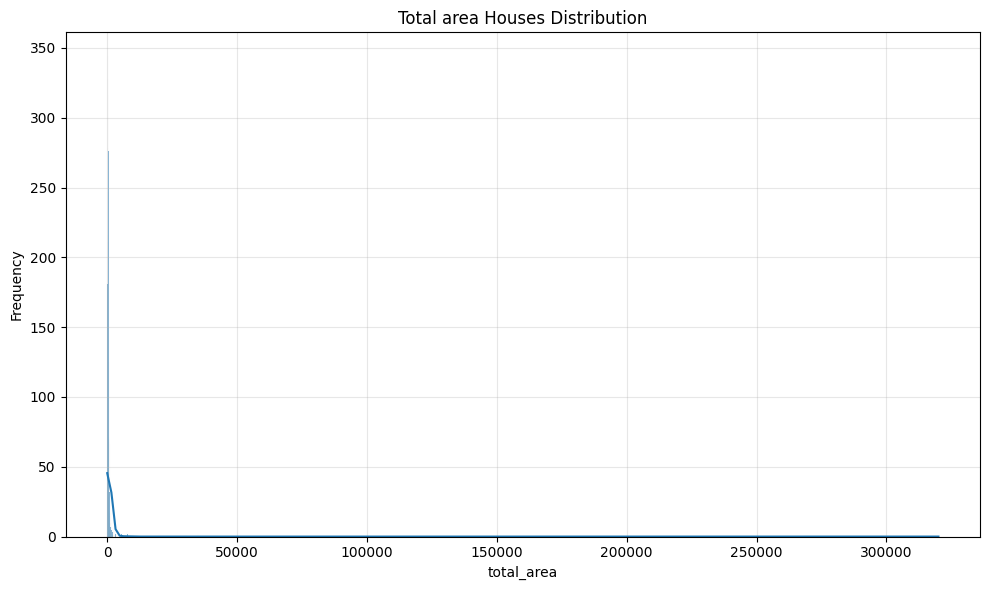

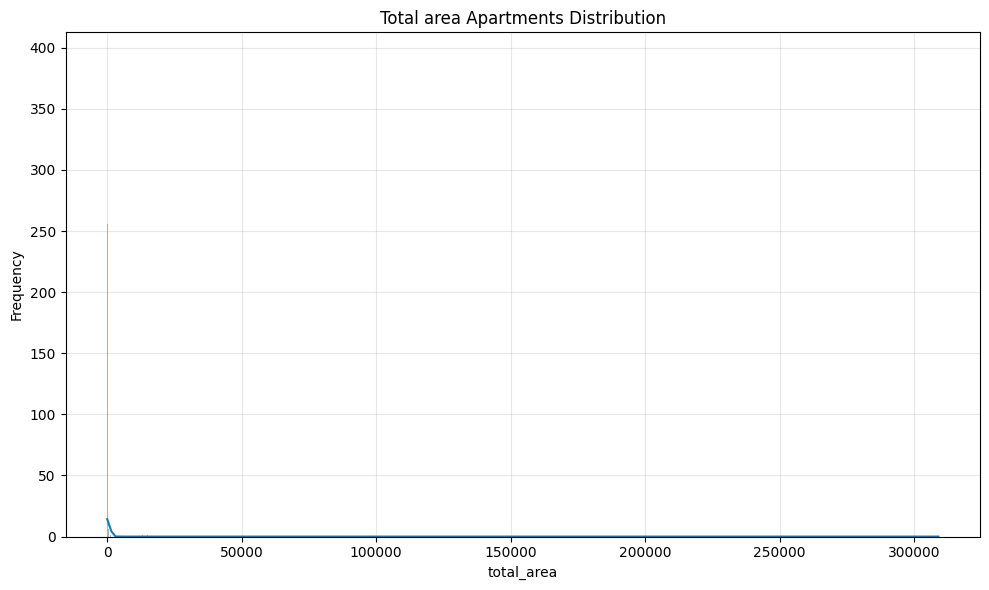

In [1624]:
plot_distribution(df_ma['total_area'],'Total area Houses Distribution','total_area')
plot_distribution(df_ap['total_area'],'Total area Apartments Distribution','total_area')

In [1625]:
df_ma['total_area']=df_ma['total_area'].fillna(df_ma['total_area'].mode())
df_ap['total_area']=df_ap['total_area'].fillna(df_ap['total_area'].mode())

C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\2685840629.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ma['total_area']=df_ma['total_area'].fillna(df_ma['total_area'].mode())
C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\2685840629.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ap['total_area']=df_ap['total_area'].fillna(df_ap['total_area'].mode())


#### Address

In [1626]:
df_clean=pd.concat([df_ap,df_ma])

In [1627]:
df_missing=df_clean[df_clean['address'].isnull()]
df_full=df_clean[df_clean['address'].notna()]
print(len(df_missing))

155


In [1628]:
# Use Nominatim API to fill in missing addresses
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
# Initialize the geocoder with rate limiting
geolocator = Nominatim(user_agent="tunisia_property_analysis")
geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)
# Function to extract location info from coordinates
def get_location_info(lat, lon):
    try:
        location = geocode((lat, lon), language='fr')
        if location and location.raw.get('address'):
            address = location.raw['address']
            municipality = address.get('city') or address.get('town') or address.get('village') or address.get('suburb')
            return municipality
        return None
    except Exception as e:
        time.sleep(2)
        return None
# Create a copy of df_missing
df_filled = df_missing.copy()
# Process in batches
batch_size = 10
total = len(df_missing)
municipalities = []

for i in range(0, total, batch_size):
    batch = df_missing.iloc[i:min(i + batch_size, total)]
    for _, row in batch.iterrows():
        municipality= get_location_info(row['latitude'], row['longitude'])
        municipalities.append(municipality)
    time.sleep(1)
# Add results to df_filled
df_filled['address'] = municipalities
# Combine with df_full

In [1629]:
df_clean = pd.concat([df_full, df_filled])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8319 entries, 0 to 217
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             8319 non-null   float64
 1   address           8296 non-null   object 
 2   total_area        7910 non-null   float64
 3   rooms             8319 non-null   float64
 4   bathrooms         8319 non-null   float64
 5   terrace           8319 non-null   float64
 6   furnished         8319 non-null   float64
 7   air_conditioning  8319 non-null   float64
 8   heating           8319 non-null   float64
 9   security          8319 non-null   float64
 10  latitude          8319 non-null   float64
 11  longitude         8319 non-null   float64
 12  bedrooms          8319 non-null   float64
 13  garage            8319 non-null   float64
 14  garden            8319 non-null   float64
 15  pool              8319 non-null   float64
 16  house             8319 non-null   float64
 17  f

In [1630]:
print(df_clean.shape)
df_clean=df_clean.dropna(subset=['address'])
print(df_clean.shape)

(8319, 18)
(8296, 18)


### c- Handling outliers

we can't jsut remove outliers the normal way because some plecas have high price values like Marsa ,gammarth and some places have low prices so it is not logic to drop outliers without introducing some categorical place difference

Same thing goes for Total area , houses tends to have more area than apartments

In [1631]:
municipality_df=pd.read_csv('municipalities.csv')
municipality_df.head()

,governorate,municipality
0,Tunis,Tunis
1,Tunis,Le Bardo
2,Tunis,Le Kram
3,Tunis,La Goulette
4,Tunis,Carthage


In [1632]:
print(municipality_df['governorate'].nunique())
print(municipality_df['governorate'].unique())


24
['Tunis' 'Ariana' 'Ben Arous' 'Manouba' 'Nabeul' 'Zaghouan' 'Bizerte'
 'Béja' 'Jendouba' 'Kef' 'Siliana' 'Sousse' 'Monastir' 'Mahdia' 'Sfax'
 'Kairouan' 'Kasserine' 'Sidi Bouzid' 'Gabès' 'Mednine' 'Tataouine'
 'Gafsa' 'Tozeur' 'Kebili']


In [1633]:
print(municipality_df['municipality'].nunique())
print(municipality_df['municipality'].unique())


270
['Tunis' 'Le Bardo' 'Le Kram' 'La Goulette' 'Carthage' 'Sidi Bou Said'
 'La Marsa' 'Sidi Hassine' 'Ariana' 'La Soukra' 'Raoued'
 'Kalâat el-Andalous' 'Sidi Thabet' 'Ettadhamen-Mnihla' 'Ben Arous'
 'El Mourouj' 'Hammam Lif' 'Hammam Chott' 'Bou Mhel el-Bassatine'
 'Ezzahra' 'Radès' 'Mégrine' 'Mohamedia-Fouchana' 'Mornag' 'Khalidia'
 'Manouba' 'Den Den' 'Douar Hicher' 'Oued Ellil' 'Mornaguia'
 'Borj El Amri' 'Djedeida' 'Tebourba' 'El Battan' 'Nabeul' 'Dar Chaabane'
 'Béni Khiar' 'El Maâmoura' 'Somâa' 'Korba' 'Tazerka' 'Menzel Temime'
 'Menzel Horr' 'El Mida' 'Kelibia' 'Azmour' 'Hammam Ghezèze' 'Dar Allouch'
 'El Haouaria' 'Takelsa' 'Soliman' 'Korbous' 'Menzel Bouzelfa'
 'Béni Khalled' 'Zaouiet Djedidi' 'Grombalia' 'Bou Argoub' 'Hammamet'
 'Zaghouan' 'Zriba' 'Bir Mcherga' 'Djebel Oust' 'El Fahs' 'Nadhour'
 'Bizerte' 'Sejnane' 'Mateur' 'Menzel Bourguiba' 'Tinja' 'Ghar al Milh'
 'Aousja' 'Menzel Jemil' 'Menzel Abderrahmane' 'El Alia' 'Ras Jebel'
 'Metline' 'Raf Raf' 'Béja' 'El Maâgoula' 

In [1634]:
df_clean["municipality"]=None
df_clean["governorate"]=None

In [1635]:
from thefuzz import process, fuzz
# Rename the misspelled columns
df_clean["municipality"] = df_clean["address"].apply(
  lambda x: process.extractOne(x, municipality_df["municipality"], scorer=fuzz.partial_ratio)[0]
)

In [1636]:
df_clean.head()

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,bedrooms,garage,garden,pool,house,floor,municipality,governorate
0,480000.0,Les Jardins de Carthage à Le Kram,118.0,3.0,1.0,1.0,0.0,0.0,0.0,1.0,36.855570,10.291834,2.0,1.0,0.0,0.0,0.0,1.0,Le Kram,None
1,720000.0,Les Jardins de Carthage à Le Kram,168.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,36.855570,10.291834,3.0,1.0,0.0,0.0,0.0,1.0,Le Kram,None
2,335000.0,Les Jardins de Carthage à Le Kram,67.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,36.855570,10.291834,2.0,0.0,0.0,0.0,0.0,1.0,Le Kram,None
4,285800.0,Cité el Ghazela à Raoued,104.0,3.0,2.0,1.0,0.0,1.0,1.0,1.0,36.954444,10.191389,2.0,1.0,0.0,0.0,0.0,6.0,Raoued,None
5,426690.0,El Kantaoui à Hammam Sousse,112.0,3.0,2.0,1.0,0.0,1.0,1.0,1.0,35.849709,10.598286,2.0,0.0,0.0,0.0,0.0,1.0,Sousse,None


In [1637]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8296 entries, 0 to 217
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             8296 non-null   float64
 1   address           8296 non-null   object 
 2   total_area        7902 non-null   float64
 3   rooms             8296 non-null   float64
 4   bathrooms         8296 non-null   float64
 5   terrace           8296 non-null   float64
 6   furnished         8296 non-null   float64
 7   air_conditioning  8296 non-null   float64
 8   heating           8296 non-null   float64
 9   security          8296 non-null   float64
 10  latitude          8296 non-null   float64
 11  longitude         8296 non-null   float64
 12  bedrooms          8296 non-null   float64
 13  garage            8296 non-null   float64
 14  garden            8296 non-null   float64
 15  pool              8296 non-null   float64
 16  house             8296 non-null   float64
 17  f

In [1638]:
municipality_lst=list(municipality_df['municipality'])
governorate_lst=list(municipality_df['governorate'])
print(len(municipality_lst))
print(len(governorate_lst))

270
270


we fill governorate based on the municipality , exemple : Manar => Ariana

In [1639]:
# Create a dictionary mapping municipalities to governorates
municipality_to_governorate = dict(zip(municipality_lst, governorate_lst))
print(municipality_to_governorate)
# Create or update the governorate column using the mapping
df_clean['governorate'] = df_clean['municipality'].map(municipality_to_governorate)

{'Tunis': 'Tunis', 'Le Bardo': 'Tunis', 'Le Kram': 'Tunis', 'La Goulette': 'Tunis', 'Carthage': 'Tunis', 'Sidi Bou Said': 'Tunis', 'La Marsa': 'Tunis', 'Sidi Hassine': 'Tunis', 'Ariana': 'Ariana', 'La Soukra': 'Ariana', 'Raoued': 'Ariana', 'Kalâat el-Andalous': 'Ariana', 'Sidi Thabet': 'Ariana', 'Ettadhamen-Mnihla': 'Ariana', 'Ben Arous': 'Ben Arous', 'El Mourouj': 'Ben Arous', 'Hammam Lif': 'Ben Arous', 'Hammam Chott': 'Ben Arous', 'Bou Mhel el-Bassatine': 'Ben Arous', 'Ezzahra': 'Ben Arous', 'Radès': 'Ben Arous', 'Mégrine': 'Ben Arous', 'Mohamedia-Fouchana': 'Ben Arous', 'Mornag': 'Ben Arous', 'Khalidia': 'Ben Arous', 'Manouba': 'Manouba', 'Den Den': 'Manouba', 'Douar Hicher': 'Manouba', 'Oued Ellil': 'Manouba', 'Mornaguia': 'Manouba', 'Borj El Amri': 'Manouba', 'Djedeida': 'Manouba', 'Tebourba': 'Manouba', 'El Battan': 'Manouba', 'Nabeul': 'Nabeul', 'Dar Chaabane': 'Nabeul', 'Béni Khiar': 'Nabeul', 'El Maâmoura': 'Nabeul', 'Somâa': 'Nabeul', 'Korba': 'Nabeul', 'Tazerka': 'Nabeul', '

In [1640]:
df_clean.head()

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,bedrooms,garage,garden,pool,house,floor,municipality,governorate
0,480000.0,Les Jardins de Carthage à Le Kram,118.0,3.0,1.0,1.0,0.0,0.0,0.0,1.0,36.855570,10.291834,2.0,1.0,0.0,0.0,0.0,1.0,Le Kram,Tunis
1,720000.0,Les Jardins de Carthage à Le Kram,168.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,36.855570,10.291834,3.0,1.0,0.0,0.0,0.0,1.0,Le Kram,Tunis
2,335000.0,Les Jardins de Carthage à Le Kram,67.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,36.855570,10.291834,2.0,0.0,0.0,0.0,0.0,1.0,Le Kram,Tunis
4,285800.0,Cité el Ghazela à Raoued,104.0,3.0,2.0,1.0,0.0,1.0,1.0,1.0,36.954444,10.191389,2.0,1.0,0.0,0.0,0.0,6.0,Raoued,Ariana
5,426690.0,El Kantaoui à Hammam Sousse,112.0,3.0,2.0,1.0,0.0,1.0,1.0,1.0,35.849709,10.598286,2.0,0.0,0.0,0.0,0.0,1.0,Sousse,Sousse


In [1641]:
df_clean['municipality'].value_counts()

municipality
Hammamet      1275
La Marsa      1070
Sousse         678
La Soukra      655
Ariana         521
              ... 
Téboursouk       1
Gremda           1
Mateur           1
Somâa            1
Skhira           1
Name: count, Length: 150, dtype: int64

#### Price column

removing prices that are miss presented

In [1642]:
print(df_clean['price'].min())
print(df_clean['price'].max())
print(df_clean.shape)
df_clean=df_clean[ (df_clean['price']>50000) & (df_clean['price']<9999999) ]
print(df_clean.shape)
print(df_clean['price'].min())
print(df_clean['price'].max())

0.0
900000000.0
(8296, 20)
(8201, 20)
55000.0
9168655.6


handling price outliers based on municipality and real state type : house or apartment

In [1643]:
def handle_outliers(df):
    # First, let's check how many rows we have before removing outliers
    print(f"Original dataframe size: {len(df)}")

    # Calculate IQR for each municipality and identify outliers
    outliers_mask = pd.Series(False, index=df.index)

    # Only process municipalities with enough data points
    min_properties = 5  # Minimum number of properties needed to calculate reliable statistics
    municipality_counts = df['municipality'].value_counts()
    valid_municipalities = municipality_counts[municipality_counts >= min_properties].index

    for municipality in valid_municipalities:
        # Get prices for this municipality
        municipality_prices = df[df['municipality'] == municipality]['price']
        
        # Calculate Q1, Q3 and IQR
        Q1 = municipality_prices.quantile(0.25)
        Q3 = municipality_prices.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds for outliers (typically 1.5 * IQR)
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers for this municipality
        municipality_outliers = df[
            (df['municipality'] == municipality) & 
            ((df['price'] < lower_bound) | (df['price'] > upper_bound))
        ].index
        
        # Add to our overall outliers mask
        outliers_mask.loc[municipality_outliers] = True
        
        # Print some stats
        outlier_count = len(municipality_outliers)
        if outlier_count > 0:
            print(f"Municipality: {municipality}, Outliers: {outlier_count}, " 
                f"Price range: {lower_bound:.2f} - {upper_bound:.2f}")

    # For municipalities with too few properties, we can use global statistics
    small_municipalities = df['municipality'].isin(
        municipality_counts[municipality_counts < min_properties].index
    )

    if small_municipalities.sum() > 0:
        # Calculate global IQR
        all_prices = df['price']
        global_Q1 = all_prices.quantile(0.25)
        global_Q3 = all_prices.quantile(0.75)
        global_IQR = global_Q3 - global_Q1
        
        global_lower = global_Q1 - 1.5 * global_IQR
        global_upper = global_Q3 + 1.5 * global_IQR
        
        # Identify outliers in small municipalities
        small_muni_outliers = df[
            small_municipalities & 
            ((df['price'] < global_lower) | (df['price'] > global_upper))
        ].index
        
        # Add to our overall outliers mask
        outliers_mask.loc[small_muni_outliers] = True
        
        print(f"\nSmall municipalities (< {min_properties} properties): "
            f"Outliers: {len(small_muni_outliers)}, "
            f"Global price range: {global_lower:.2f} - {global_upper:.2f}")

    # Remove the outliers
    df_clean_no_outliers = df[~outliers_mask].copy()

    # Print summary
    total_outliers = outliers_mask.sum()
    print(f"\nTotal outliers removed: {total_outliers} ({total_outliers/len(df)*100:.2f}%)")
    print(f"Dataframe size after removing outliers: {len(df_clean_no_outliers)}")

    # Replace the original dataframe with the cleaned one
    df = df_clean_no_outliers

    # Show the price distribution after removing outliers
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.hist(df['price'], bins=50)
    plt.title('Price Distribution After Removing Outliers')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()
    return df

handling price outliers in apartments
Original dataframe size: 4306
Municipality: La Marsa, Outliers: 32, Price range: -275000.00 - 1365000.00
Municipality: Hammamet, Outliers: 22, Price range: -47500.00 - 772500.00
Municipality: Sousse, Outliers: 30, Price range: 0.00 - 720000.00
Municipality: La Soukra, Outliers: 8, Price range: -66250.00 - 871750.00
Municipality: Le Kram, Outliers: 15, Price range: -80750.00 - 1361250.00
Municipality: Ariana, Outliers: 11, Price range: -82500.00 - 817500.00
Municipality: Nabeul, Outliers: 7, Price range: -10000.00 - 710000.00
Municipality: Tunis, Outliers: 18, Price range: -25000.00 - 495000.00
Municipality: Raoued, Outliers: 3, Price range: -34675.00 - 628125.00
Municipality: El Mida, Outliers: 5, Price range: 47250.00 - 651250.00
Municipality: Kelibia, Outliers: 5, Price range: 3750.00 - 393750.00
Municipality: Akouda, Outliers: 2, Price range: -30000.00 - 690000.00
Municipality: Hergla, Outliers: 6, Price range: -39600.00 - 650000.00
Municipality

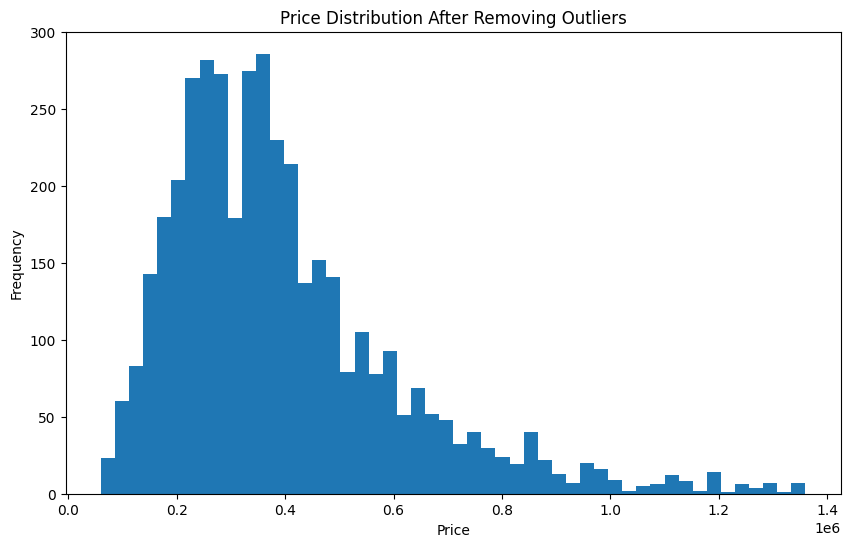

handling price outliers in houses
Original dataframe size: 3895
Municipality: Hammamet, Outliers: 39, Price range: -25000.00 - 1775000.00
Municipality: La Marsa, Outliers: 8, Price range: -817500.00 - 4010500.00
Municipality: La Soukra, Outliers: 24, Price range: -75000.00 - 2365000.00
Municipality: Sousse, Outliers: 7, Price range: -1225000.00 - 3295000.00
Municipality: Ariana, Outliers: 5, Price range: -380645.50 - 2353742.50
Municipality: Ajim (Djerba), Outliers: 6, Price range: -61175.00 - 1155345.00
Municipality: Kelibia, Outliers: 15, Price range: -600000.00 - 1640000.00
Municipality: Nabeul, Outliers: 10, Price range: -618125.00 - 2706875.00
Municipality: El Mida, Outliers: 4, Price range: -76875.00 - 2606125.00
Municipality: Tunis, Outliers: 4, Price range: -867767.75 - 3160660.65
Municipality: Raoued, Outliers: 4, Price range: -216250.00 - 1293750.00
Municipality: Bizerte, Outliers: 6, Price range: -425000.00 - 1535000.00
Municipality: Akouda, Outliers: 5, Price range: -196872

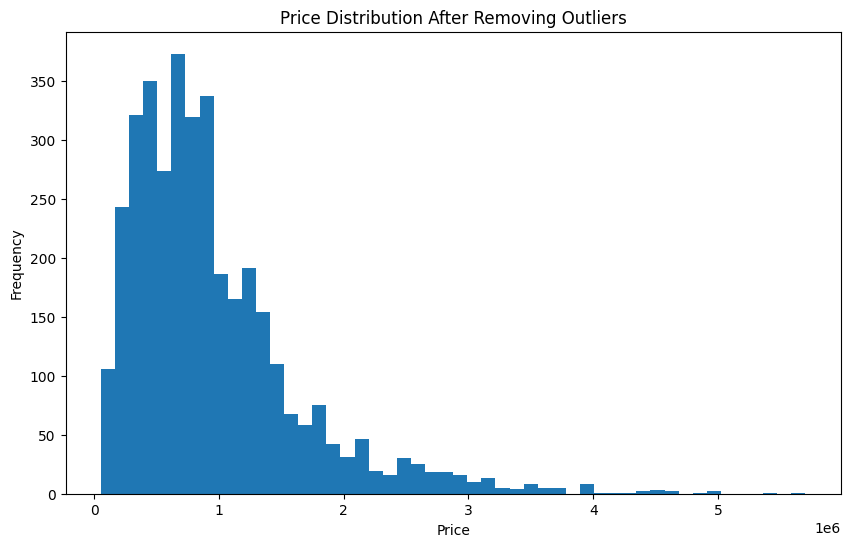

In [1644]:
df_ap=df_clean[df_clean['house']==0]
df_ma=df_clean[df_clean['house']==1]
print("handling price outliers in apartments")
df_ap=handle_outliers(df_ap)
print("handling price outliers in houses")
df_ma=handle_outliers(df_ma)


In [ ]:
print("Houses bebore IQR outlier removal",df_ap.shape)
print("Apartments before IQR outlier removal",df_ma.shape)
# Method 1: IQR (Interquartile Range) method
def remove_outliers_iqr(df, column, k=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Try the IQR method
for col in ["total_area"]:
    df_ap = remove_outliers_iqr(df_ap, col)
    df_ma = remove_outliers_iqr(df_ma, col)
    print(f"After IQR outlier removal on {col}: {df_ap.shape}")
    print(f"After IQR outlier removal on {col}: {df_ma.shape}")




After IQR outlier removal on total_area: (3727, 20)
After IQR outlier removal on total_area: (3274, 20)


In [1646]:
def remove_outliers_zscore(df, column, threshold=3):
    # Calculate the Z-score for each data point
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    # Filter out the outliers
    return df[np.abs(z_scores) < threshold]

In [1648]:

print(df_ma.shape)
print(df_ap.shape)
for col in ['bedrooms','rooms','bathrooms','floor']:
    df_ma=remove_outliers_zscore(df_ma,col)
    df_ap=remove_outliers_zscore(df_ap,col)
print(df_ma.shape)
print(df_ap.shape)

    


(3274, 20)
(3727, 20)
(3129, 20)
(3529, 20)


In [1649]:
df_clean=pd.concat([df_ma,df_ap])
print(df_clean.shape)

(6658, 20)


## 2-Feature engineering and selection

(1023, 19)


<Axes: xlabel='latitude', ylabel='longitude'>

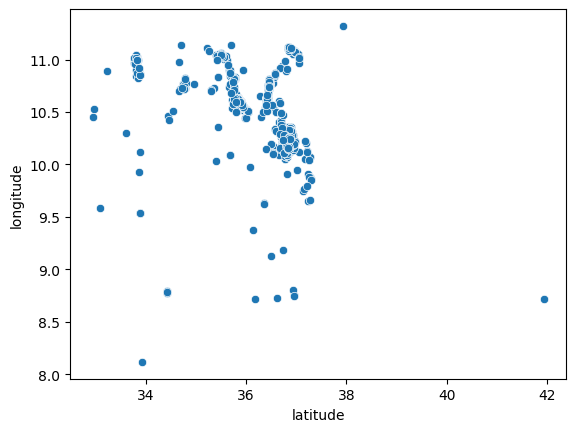

In [1206]:
# Drop duplicate rows based on latitude and longitude
data_geo = df_clean.drop_duplicates(subset=['latitude', 'longitude'])
# Reset index to ensure no duplicate labels
data_geo.reset_index(drop=True, inplace=True)
print(data_geo.shape)
# Plot the scatterplot
sns.scatterplot(x='latitude', y='longitude', data=data_geo)

In [1650]:
# Round latitude and longitude to 4 decimal places
df_clean['latitude'] = df_clean['latitude'].round(4)
df_clean['longitude'] = df_clean['longitude'].round(4)
# Check the rounded values
print(df_clean[['latitude', 'longitude']].head())

      latitude  longitude
4891   36.8764    10.3253
4893   36.3884    10.5515
4895   36.4011    10.6146
4896   36.4011    10.6146
4898   36.8355    10.2242


In [1655]:
df_clean.groupby('municipality')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
municipality,,,,,,,,
Ajim (Djerba),157.0,5.538316e+05,212390.189884,179000.00,390000.00,496580.0,689800.00,1148560.00
Akouda,103.0,5.478088e+05,737013.760811,60000.00,250000.00,360000.0,541993.67,4889950.78
Ariana,454.0,6.012185e+05,453341.456433,110000.00,302375.00,430000.0,737500.00,2300000.00
Aïn Draham,2.0,1.225000e+05,38890.872965,95000.00,108750.00,122500.0,136250.00,150000.00
Bekalta,3.0,1.733333e+05,5773.502692,170000.00,170000.00,170000.0,175000.00,180000.00
...,...,...,...,...,...,...,...,...
Tunis,149.0,6.632163e+05,670128.356556,85000.00,198000.00,309000.0,890000.00,2500000.00
Téboulba,10.0,2.895759e+05,170645.058876,105000.00,177500.00,244219.0,365000.00,573660.36
Zaghouan,6.0,5.720943e+05,229605.509902,300000.00,422500.00,560000.0,654424.44,950000.00


In [1656]:
# Calculate average price per municipality
municipality_avg_price = df_clean.groupby('municipality')['price'].mean().reset_index()
municipality_avg_price.columns = ['municipality', 'municipality_avg_price']
# Calculate average price per governorate
governorate_avg_price = df_clean.groupby('governorate')['price'].mean().reset_index()
governorate_avg_price.columns = ['governorate', 'governorate_avg_price']
df_clean = pd.merge(df_clean, municipality_avg_price, on='municipality', how='left')
df_clean = pd.merge(df_clean, governorate_avg_price, on='governorate', how='left')
df_clean.head()

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,...,bedrooms,garage,garden,pool,house,floor,municipality,governorate,municipality_avg_price,governorate_avg_price
0,856000.0,Gammarth à La Marsa,405.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,1.0,2,La Marsa,Tunis,855591.608000,808797.776463
1,892000.0,Hammamet Sud à Hammamet,485.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,...,4.0,1.0,1.0,1.0,1.0,1,Hammamet,Nabeul,617984.126858,594225.102625
2,1250000.0,Hammamet Nord à Hammamet,370.0,5.0,3.0,1.0,0.0,1.0,1.0,0.0,...,4.0,1.0,1.0,1.0,1.0,1,Hammamet,Nabeul,617984.126858,594225.102625
3,1150000.0,Hammamet Sud à Hammamet,550.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,...,4.0,1.0,1.0,1.0,1.0,2,Hammamet,Nabeul,617984.126858,594225.102625
4,2200000.0,Les Berges Du Lac 1 à La Marsa,438.0,8.0,4.0,1.0,0.0,1.0,1.0,1.0,...,6.0,1.0,1.0,1.0,1.0,2,La Marsa,Tunis,855591.608000,808797.776463


In [1657]:
def generate_quality(col):
    # Create municipality quality feature based on average prices
    # Group by municipality and calculate statistics
    stats = df_clean.groupby(col).agg({
        'price': ['mean', 'median', 'count']
    }).reset_index()

    # Flatten the multi-index columns
    stats.columns = [col, 'avg_price', 'median_price', 'property_count']

    # Separate reliable and unreliable
    min_samples = 3  # Minimum number of properties to consider reliable
    reliable = stats[stats['property_count'] >= min_samples]
    unreliable = stats[stats['property_count'] < min_samples]

    # Create quality tiers for reliable 
    if len(reliable) > 0:
        # Calculate price thresholds from reliable data
        low_threshold = reliable['avg_price'].quantile(0.33)
        high_threshold = reliable['avg_price'].quantile(0.67)
        
        # Create quality tiers using calculated thresholds
        reliable['price_tier'] = pd.cut(
            reliable['avg_price'],
            bins=[0, low_threshold, high_threshold, float('inf')],
            labels=['low_income_area', 'middle_income_area', 'high_income_area']
        )
        reliable['confidence'] = 'high'
    if len(unreliable) > 0:
        # Apply the same thresholds to unreliable municipalities
        unreliable['price_tier'] = pd.cut(
            unreliable['avg_price'],
            bins=[0, low_threshold, high_threshold, float('inf')],
            labels=['low_income_area', 'middle_income_area', 'high_income_area']
        )
        unreliable['confidence'] = 'low'
        
    # Combine all municipalities
    all_municipalities = pd.concat([reliable, unreliable]) 
    # Create mapping dictionaries
    quality_map = dict(zip(
        all_municipalities[col], 
        all_municipalities['price_tier']
    ))
        
    confidence_map = dict(zip(
        all_municipalities[col], 
        all_municipalities['confidence']
    ))
    return quality_map,confidence_map


In [1658]:
# Apply the mappings to create new features
municipality_quality_map_mun,municipality_confidence_map_mun=generate_quality('municipality')
df_clean['municipality_quality'] = df_clean['municipality'].map(municipality_quality_map_mun)
df_clean['municipality_quality_confidence'] = df_clean['municipality'].map(municipality_confidence_map_mun)

municipality_quality_map_gov,municipality_confidence_map_gov=generate_quality('governorate')
df_clean['governorate_quality'] = df_clean['governorate'].map(municipality_quality_map_gov)
df_clean['governorate_quality_confidence'] = df_clean['governorate'].map(municipality_confidence_map_gov)


df_clean.head()

C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\4020268722.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable['price_tier'] = pd.cut(
C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\4020268722.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable['confidence'] = 'high'
C:\Users\MSI\AppData\Local\Temp\ipykernel_17676\4020268722.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,...,house,floor,municipality,governorate,municipality_avg_price,governorate_avg_price,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,856000.0,Gammarth à La Marsa,405.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2,La Marsa,Tunis,855591.608000,808797.776463,high_income_area,high,high_income_area,high
1,892000.0,Hammamet Sud à Hammamet,485.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1,Hammamet,Nabeul,617984.126858,594225.102625,high_income_area,high,high_income_area,high
2,1250000.0,Hammamet Nord à Hammamet,370.0,5.0,3.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1,Hammamet,Nabeul,617984.126858,594225.102625,high_income_area,high,high_income_area,high
3,1150000.0,Hammamet Sud à Hammamet,550.0,5.0,4.0,1.0,0.0,1.0,1.0,0.0,...,1.0,2,Hammamet,Nabeul,617984.126858,594225.102625,high_income_area,high,high_income_area,high
4,2200000.0,Les Berges Du Lac 1 à La Marsa,438.0,8.0,4.0,1.0,0.0,1.0,1.0,1.0,...,1.0,2,La Marsa,Tunis,855591.608000,808797.776463,high_income_area,high,high_income_area,high


In [1659]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6658 entries, 0 to 6657
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            6658 non-null   float64
 1   address                          6658 non-null   object 
 2   total_area                       6658 non-null   float64
 3   rooms                            6658 non-null   float64
 4   bathrooms                        6658 non-null   float64
 5   terrace                          6658 non-null   float64
 6   furnished                        6658 non-null   float64
 7   air_conditioning                 6658 non-null   float64
 8   heating                          6658 non-null   float64
 9   security                         6658 non-null   float64
 10  latitude                         6658 non-null   float64
 11  longitude                        6658 non-null   float64
 12  bedrooms            

### Encoding

In [1660]:
df_clean.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool', 'house', 'floor',
       'municipality', 'governorate', 'municipality_avg_price',
       'governorate_avg_price', 'municipality_quality',
       'municipality_quality_confidence', 'governorate_quality',
       'governorate_quality_confidence'],
      dtype='object')

In [1661]:
# Using pandas get_dummies for categorical variables
import pandas as pd

# List of categorical columns to convert
categorical_columns = [  'municipality_quality', 'municipality_quality_confidence',
       'governorate_quality', 'governorate_quality_confidence']

# Filter to only include columns that exist in the dataframe
categorical_columns = [col for col in categorical_columns if col in df_clean.columns]

if categorical_columns:
    # Create dummy variables and drop original columns
    df_clean = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=False)
else:
    print("No categorical columns found in the dataframe")

In [1662]:
df_clean=df_clean.drop(columns=['municipality','governorate','address'],axis=1)

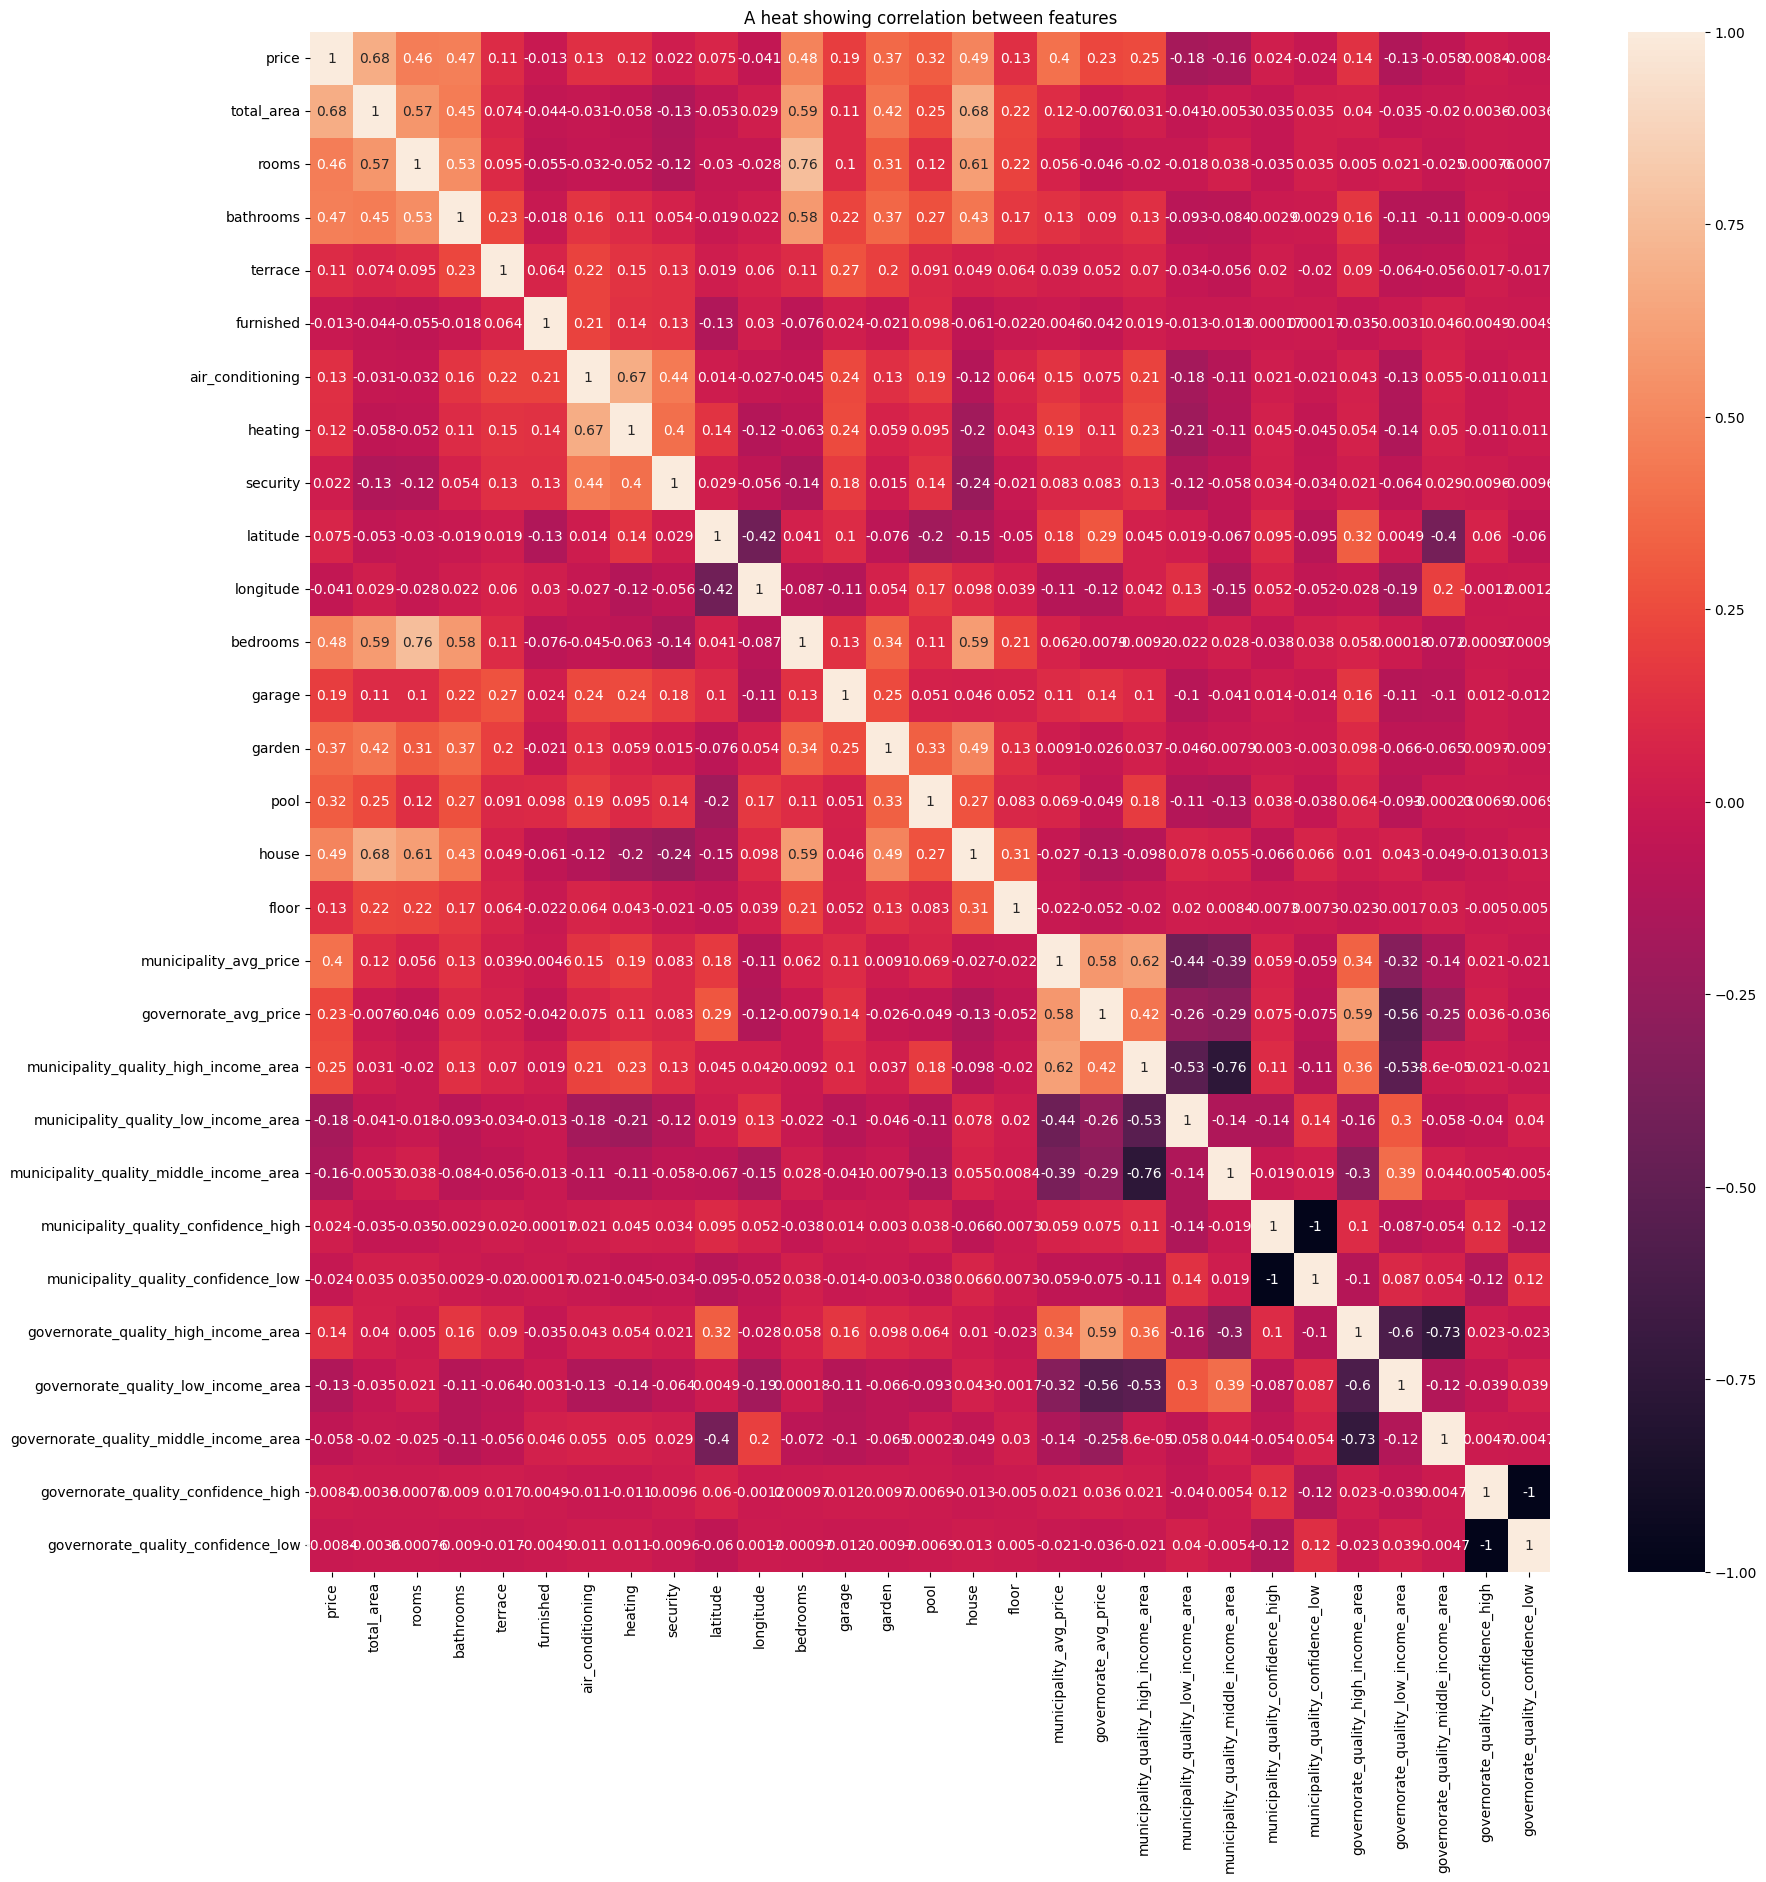

In [1663]:
plt.figure(figsize=(20, 20))
sns.heatmap(df_clean.corr(), annot=True)
plt.title("A heat showing correlation between features")
plt.show()


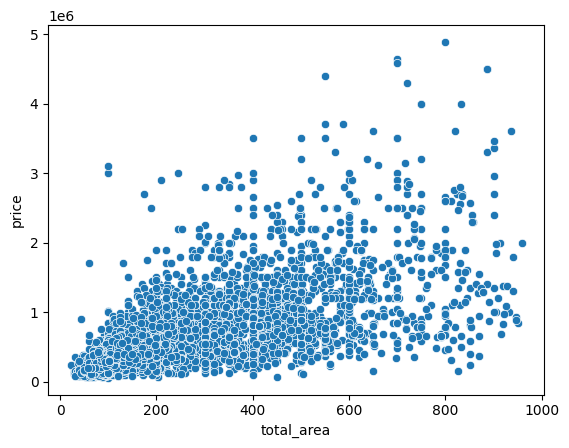

In [1664]:
sns.scatterplot(x='total_area',y='price',data=df_clean)
plt.show()

In [1218]:
#df_clean.to_csv('generate_from.csv',index=False)

In [1219]:
#df_clean=pd.read_csv('synthatic_data_maison_acheter.csv')
#df_clean=df_clean.dropna()

## Modeling

In [1665]:
df_clean.columns

Index(['price', 'total_area', 'rooms', 'bathrooms', 'terrace', 'furnished',
       'air_conditioning', 'heating', 'security', 'latitude', 'longitude',
       'bedrooms', 'garage', 'garden', 'pool', 'house', 'floor',
       'municipality_avg_price', 'governorate_avg_price',
       'municipality_quality_high_income_area',
       'municipality_quality_low_income_area',
       'municipality_quality_middle_income_area',
       'municipality_quality_confidence_high',
       'municipality_quality_confidence_low',
       'governorate_quality_high_income_area',
       'governorate_quality_low_income_area',
       'governorate_quality_middle_income_area',
       'governorate_quality_confidence_high',
       'governorate_quality_confidence_low'],
      dtype='object')

In [ ]:
#df_clean.to_csv('apocalypse.csv',index=False)
df_clean=pd.read_csv('synthatic_data.csv')
df_clean=df_clean.dropna()

In [1679]:
X=df_clean.drop(columns=['price','governorate_quality_confidence_low','governorate_quality_middle_income_area',
                        'municipality_quality_confidence_low','municipality_quality_middle_income_area'],axis=1)
y=df_clean['price']
print(X.shape)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

(26633, 24)


In [1680]:
# Define MAPE and MdAPE functions
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def median_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [1681]:
# Define the function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name=None):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    # Calculate MAPE and MdAPE
    train_mape = mean_absolute_percentage_error(y_train, train_pred)
    test_mape = mean_absolute_percentage_error(y_test, test_pred)
    train_mdape = median_absolute_percentage_error(y_train, train_pred)
    test_mdape = median_absolute_percentage_error(y_test, test_pred)
    
    name = model_name if model_name else model.__class__.__name__
    print(f"\nModel: {name}")
    print(f"Training R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
    print(f"Training MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    print(f"Training RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")
    print(f"Training MAPE: {train_mape:.2f}%, Test MAPE: {test_mape:.2f}%")
    print(f"Training MdAPE: {train_mdape:.2f}%, Test MdAPE: {test_mdape:.2f}%")
    print(f"R² Difference (Overfitting): {train_r2 - test_r2:.4f}")

In [1670]:
from sklearn.model_selection import cross_val_score
def cross_val_evaluate(model):
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nCross-validation R² scores: {cv_scores}")
    print(f"Mean CV R² score: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation of CV R² scores: {np.std(cv_scores):.4f}")

    # Get feature importances
    feature_importances = model.feature_importances_
    features = X_train.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.gca().invert_yaxis()  # Display the most important feature at the top
    plt.tight_layout()
    plt.show()

#### Linear Regression

In [1682]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
lr=LinearRegression()
# Add StandardScaler for feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test,"Linear Regression")



Model: Linear Regression
Training R²: 0.5840, Test R²: 0.5699
Training MAE: 186971.21, Test MAE: 192990.42
Training RMSE: 291962.64, Test RMSE: 301280.63
Training MAPE: 48.10%, Test MAPE: 49.37%
Training MdAPE: 30.15%, Test MdAPE: 31.15%
R² Difference (Overfitting): 0.0141


### Random forest

Starting hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'oob_score': True, 'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_samples': 0.7, 'max_features': 0.5, 'max_depth': 15, 'bootstrap': True}
Best cross-validation MSE: 67702961869.29

Model: Random forest
Training R²: 0.7673, Test R²: 0.6658
Training MAE: 129187.86, Test MAE: 159084.27
Training RMSE: 218378.61, Test RMSE: 265561.33
Training MAPE: 31.00%, Test MAPE: 37.99%
Training MdAPE: 18.96%, Test MdAPE: 23.09%
R² Difference (Overfitting): 0.1015

Cross-validation R² scores: [0.68274947 0.65879656 0.68932046 0.6572956  0.66606863]
Mean CV R² score: 0.6708
Standard deviation of CV R² scores: 0.0129


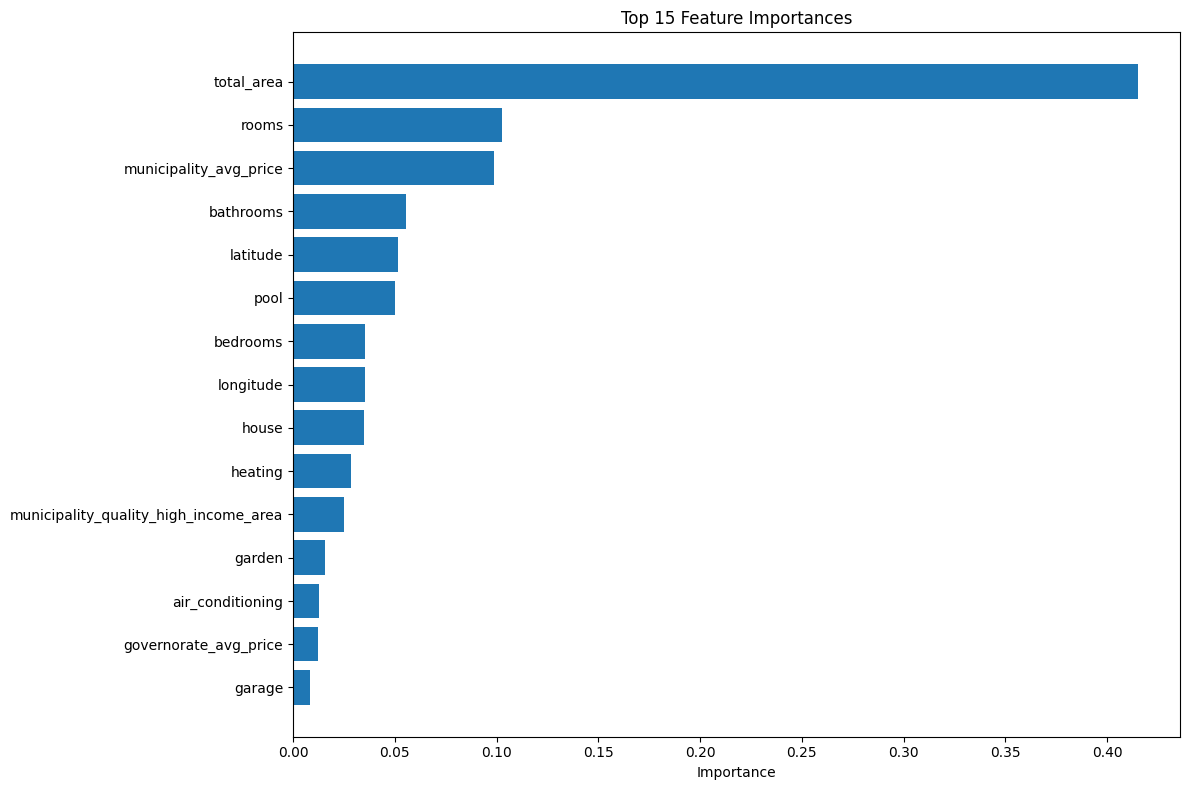

In [1683]:
# Hyperparameter tuning for Random Forest with focus on reducing overfitting
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
# Define the parameter distribution with more regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Include more restrictive depths
    'min_samples_split': [5, 10, 15, 20, 25],  # Increase minimum samples for splits
    'min_samples_leaf': [2, 4, 6, 8, 10],      # Increase minimum samples for leaves
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap': [True],
    'oob_score': [True],
    'max_samples': [0.7, 0.8, 0.9, None]  # Add subsampling to reduce overfitting
}
# Create a base Random Forest model
rf = RandomForestRegressor(random_state=42)
# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_squared_error'  # Focus on error minimization
)
# Fit RandomizedSearchCV
print("Starting hyperparameter search...")
rf_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {rf_random.best_params_}")
print(f"Best cross-validation MSE: {-rf_random.best_score_:.2f}")

# Create a model with the best parameters
best_rf = RandomForestRegressor(**rf_random.best_params_, random_state=42)
evaluate_model(best_rf, X_train, X_test, y_train, y_test,"Random forest")

cross_val_evaluate(best_rf)


### GradientBoostingRegressor

Starting hyperparameter search for Gradient Boosting...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'subsample': 1.0, 'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 6, 'learning_rate': 0.05, 'alpha': 0.5}
Best cross-validation MSE: 65661100853.95

Model: Gradient boost regressor
Training R²: 0.7741, Test R²: 0.6733
Training MAE: 133446.90, Test MAE: 157873.68
Training RMSE: 215154.65, Test RMSE: 262546.56
Training MAPE: 32.66%, Test MAPE: 37.43%
Training MdAPE: 20.56%, Test MdAPE: 23.12%
R² Difference (Overfitting): 0.1007

Cross-validation R² scores: [0.68933723 0.67111491 0.70253263 0.66225621 0.67325254]
Mean CV R² score: 0.6797
Standard deviation of CV R² scores: 0.0144


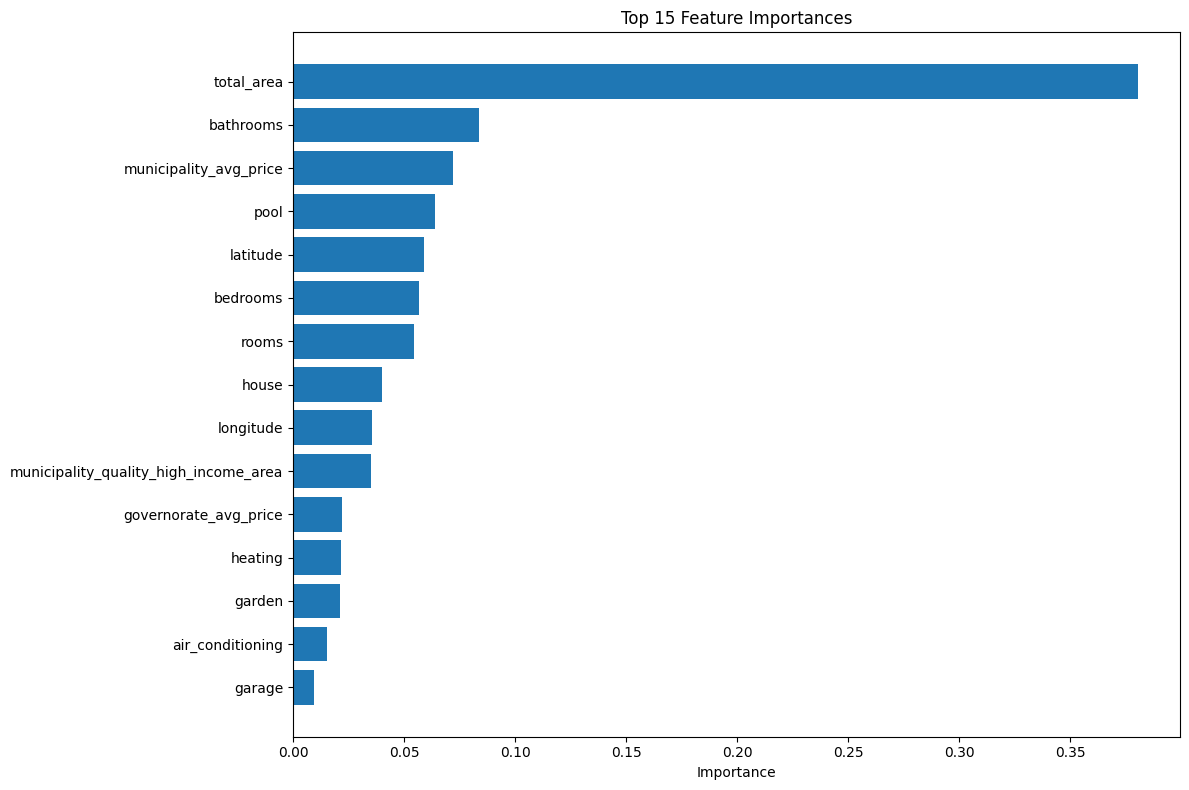

In [1684]:
# Hyperparameter tuning for Gradient Boosting with focus on reducing overfitting
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

# Define the parameter distribution with regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 4, 5, 6, 8],  # GBM typically uses shallower trees than RF
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # Similar to max_samples in RF
    'alpha': [0.1, 0.5, 0.9]  # Alpha for quantile loss (controls robustness)
}

# Create a base Gradient Boosting model
sgb = GradientBoostingRegressor(random_state=42)

# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
sgb_random = RandomizedSearchCV(
    estimator=sgb,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_squared_error'  # Focus on error minimization
)

# Fit RandomizedSearchCV
print("Starting hyperparameter search for Gradient Boosting...")
sgb_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {sgb_random.best_params_}")
print(f"Best cross-validation MSE: {-sgb_random.best_score_:.2f}")
# Create a model with the best parameters
best_sgb = GradientBoostingRegressor(**sgb_random.best_params_, random_state=42)
evaluate_model(best_sgb, X_train, X_test, y_train, y_test,"Gradient boost regressor")
cross_val_evaluate(best_sgb)

### Ensemble 

In [ ]:
# ... existing code ...
from sklearn.ensemble import VotingRegressor, StackingRegressor
# Define the best Lasso model

# Simple averaging ensemble (VotingRegressor) with Lasso added
voting_ensemble = VotingRegressor(
    estimators=[
        ('rf', best_rf),
        ('sgb', best_sgb),
        ('lr', lr),
    ],
    weights=[1, 1,1]  # Equal weights for all models
)

evaluate_model(voting_ensemble, X_train, X_test, y_train, y_test,"Voting ensemble")


# Advanced stacking ensemble with a meta-learner and Lasso added
stacking_ensemble = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('sgb', best_sgb),
        ('lr', lr),
    ],)
evaluate_model(voting_ensemble, X_train, X_test, y_train, y_test,"stacking ensemble")


Model: Voting ensemble
Training R²: 0.7357, Test R²: 0.6594
Training MAE: 142564.29, Test MAE: 162938.17
Training RMSE: 232705.86, Test RMSE: 268075.93
Training MAPE: 35.18%, Test MAPE: 39.56%
Training MdAPE: 22.12%, Test MdAPE: 24.24%
R² Difference (Overfitting): 0.0763

Model: Voting ensemble
Training R²: 0.7357, Test R²: 0.6594
Training MAE: 142564.29, Test MAE: 162938.17
Training RMSE: 232705.86, Test RMSE: 268075.93
Training MAPE: 35.18%, Test MAPE: 39.56%
Training MdAPE: 22.12%, Test MdAPE: 24.24%
R² Difference (Overfitting): 0.0763


### Deep learning

In [1905]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define neural network for regression
class RealEstateNN(nn.Module):
    def __init__(self, input_dim):
        super(RealEstateNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# Train and evaluate the model
def train_and_evaluate_nn(X_train, y_train, X_test, y_test, epochs=300, batch_size=64):
    # Scale features
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Log transform the target for better training
    y_train_log = np.log1p(y_train)
    
    # Scale the log-transformed target
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train_log.values.reshape(-1, 1)).flatten()
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    y_train_tensor = torch.FloatTensor(y_train_scaled)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    
    # Create dataset and dataloader
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    input_dim = X_train.shape[1]
    model = RealEstateNN(input_dim)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            # Forward pass
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        scheduler.step(avg_loss)
        
        # Print progress
        if (epoch+1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    
    # Evaluation on original price scale
    model.eval()
    with torch.no_grad():
        # Get predictions
        y_pred_scaled = model(X_test_tensor).squeeze().numpy()
        
        # Convert back to log space
        y_pred_log = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        
        # Convert from log space to original price
        y_pred = np.expm1(y_pred_log)
        
        # Calculate metrics on original price scale
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        mdape = median_absolute_percentage_error(y_test, y_pred)

        print("\nNeural Network Performance (Original Price Scale):")
        print(f"MAE: {mae:.2f} TND")
        print(f"RMSE: {rmse:.2f} TND")
        print(f"R²: {r2:.4f}")
        print("mape:",mape)
        print("mdape",mdape)
    
    return model, y_pred

# Train and evaluate the model
model, predictions = train_and_evaluate_nn(X_train, y_train, X_test, y_test)

Epoch [50/300], Loss: 0.2115
Epoch [100/300], Loss: 0.1694
Epoch [150/300], Loss: 0.1469
Epoch [200/300], Loss: 0.1267
Epoch [250/300], Loss: 0.1151
Epoch [300/300], Loss: 0.1221

Neural Network Performance (Original Price Scale):
MAE: 73295.92 TND
RMSE: 105901.17 TND
R²: 0.6738
mape: 22.37593887597262
mdape 15.21922508445946
